<a href="https://colab.research.google.com/github/Progra-man/dap-2024/blob/main/les08/Lab8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №8. Кластеризация

Python version: 3.10.12 (main, Nov  6 2024, 20:22:13) [GCC 11.4.0]
Numpy version: 1.26.4
Pandas version: 2.2.2
Matplotlib version: 3.8.0


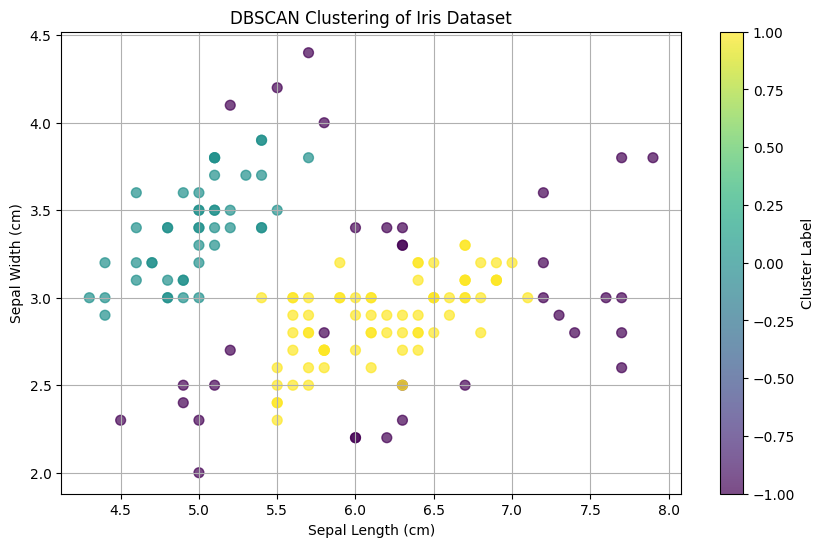

Количество кластеров: 2
Количество шумовых точек: 34
cluster
-1    34
 0    45
 1    71
dtype: int64


In [ ]:
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# Версии используемых библиотек
print(f"Python version: {sys.version}")
print(f"Numpy version: {np.version.version}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {mpl.__version__}")

# Шаг 1: Импорт данных
iris = load_iris()
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['target'] = iris.target
data['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Вывод первых 5 строк для проверки
data.head()

# Шаг 2: Нормализация данных
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.iloc[:, :4])

# Шаг 3: Кластеризация с использованием DBSCAN
# Подбираем параметры eps и min_samples
# eps: радиус для определения соседей точки
# min_samples: минимальное количество точек для формирования кластера
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(data_scaled)
data['cluster'] = clusters

# Шаг 4: Построение диаграммы рассеяния
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    data['sepal length (cm)'], data['sepal width (cm)'], c=data['cluster'], cmap='viridis', s=50, alpha=0.7
)
plt.colorbar(scatter, label='Cluster Label')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('DBSCAN Clustering of Iris Dataset')
plt.grid(True)
plt.show()

# Шаг 5: Вывод
unique_clusters = set(clusters)
noise_points = list(clusters).count(-1)
print(f"Количество кластеров: {len(unique_clusters) - (1 if -1 in unique_clusters else 0)}")
print(f"Количество шумовых точек: {noise_points}")

# Вывод значений для проверки корректности кластеризации
print(data.groupby('cluster').size())